# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('vader_lexicon')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Load Dataset

In [2]:
df = pd.read_csv("Mental-Health-Twitter.csv")

# Display basic information
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    20000 non-null  int64 
 1   post_id       20000 non-null  int64 
 2   post_created  20000 non-null  object
 3   post_text     20000 non-null  object
 4   user_id       20000 non-null  int64 
 5   followers     20000 non-null  int64 
 6   friends       20000 non-null  int64 
 7   favourites    20000 non-null  int64 
 8   statuses      20000 non-null  int64 
 9   retweets      20000 non-null  int64 
 10  label         20000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 1.7+ MB
None
   Unnamed: 0             post_id                    post_created  \
0           0  637894677824413696  Sun Aug 30 07:48:37 +0000 2015   
1           1  637890384576778240  Sun Aug 30 07:31:33 +0000 2015   
2           2  637749345908051968  Sat Aug 29 22:11:07 +0000 2015   
3           3 

# Data Preprocessing

In [3]:
# Text Cleaning Functions
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert to string
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove emojis and special characters
    text = re.sub(r'[^A-Za-z\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenization
    tokens = nltk.word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

# Apply Preprocessing

df['clean_text'] = df['post_text'].apply(clean_text)

print(df[['post_text', 'clean_text']].head())

                                           post_text  \
0  It's just over 2 years since I was diagnosed w...   
1  It's Sunday, I need a break, so I'm planning t...   
2  Awake but tired. I need to sleep but my brain ...   
3  RT @SewHQ: #Retro bears make perfect gifts and...   
4  It’s hard to say whether packing lists are mak...   

                                          clean_text  
0  year since diagnosed today taking moment refle...  
1  sunday need break planning spend little time p...  
2                  awake tired need sleep brain idea  
3  bear make perfect gift great beginner get stit...  
4  hard say whether packing list making life easi...  


# Feature Engineering

In [4]:
# Bag-of-Words Representation
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])

print("BoW feature shape:", X_bow.shape)

BoW feature shape: (20000, 5000)


In [5]:
# TF-IDF Representation
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print("TF-IDF feature shape:", X_tfidf.shape)

TF-IDF feature shape: (20000, 5000)


In [6]:
# Sentiment Analysis (VADER)
sid = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    scores = sid.polarity_scores(text)
    return scores['compound'], scores['pos'], scores['neg'], scores['neu']

df[['sent_compound', 'sent_pos', 'sent_neg', 'sent_neu']] = (
    df['clean_text']
    .apply(get_sentiment_scores)
    .apply(pd.Series)
)

print(df[['sent_compound', 'sent_pos', 'sent_neg', 'sent_neu']].head())

   sent_compound  sent_pos  sent_neg  sent_neu
0         0.0000     0.000     0.000     1.000
1         0.0000     0.000     0.000     1.000
2        -0.4404     0.000     0.367     0.633
3         0.8934     0.572     0.000     0.428
4         0.3400     0.197     0.099     0.704


In [7]:
# Linguistic Features
def linguistic_features(text):
    tokens = text.split()
    word_count = len(tokens)
    pronoun_count = sum(1 for word in tokens if word in ['i', 'me', 'my', 'mine'])
    emotion_words = ['sad', 'depressed', 'lonely', 'hopeless', 'tired', 'anxious']
    emotion_count = sum(1 for word in tokens if word in emotion_words)
    return word_count, pronoun_count, emotion_count

df[['word_count', 'pronoun_count', 'emotion_word_count']] = (
    df['clean_text']
    .apply(linguistic_features)
    .apply(pd.Series)
)

print(df[['word_count', 'pronoun_count', 'emotion_word_count']].head())

   word_count  pronoun_count  emotion_word_count
0          11              0                   0
1           8              0                   0
2           6              0                   1
3          11              0                   0
4          12              0                   0


In [8]:
# Target Variable
y = df['label']

print("Target distribution:")
print(y.value_counts())


Target distribution:
label
1    10000
0    10000
Name: count, dtype: int64


# EDA

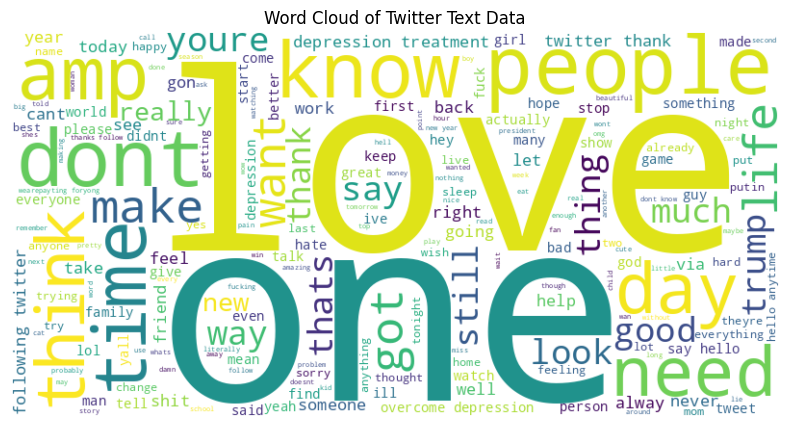

In [9]:
# Word Cloud
all_text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Twitter Text Data")
plt.show()

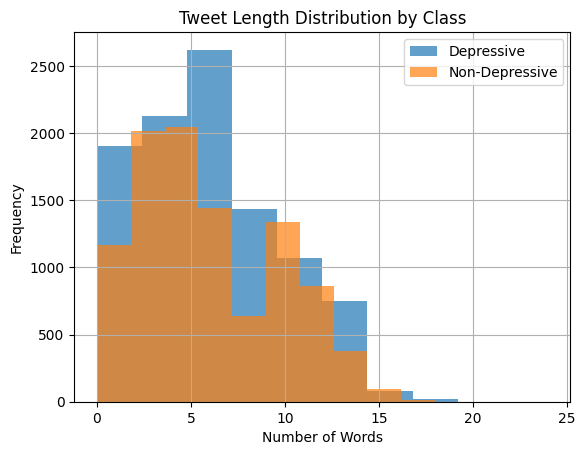

In [10]:
# Tweet Length Distribution
df['tweet_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure()
df[df['label'] == 1]['tweet_length'].hist(alpha=0.7)
df[df['label'] == 0]['tweet_length'].hist(alpha=0.7)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Tweet Length Distribution by Class")
plt.legend(["Depressive", "Non-Depressive"])
plt.show()

/tmp/ipykernel_8268/2808546317.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


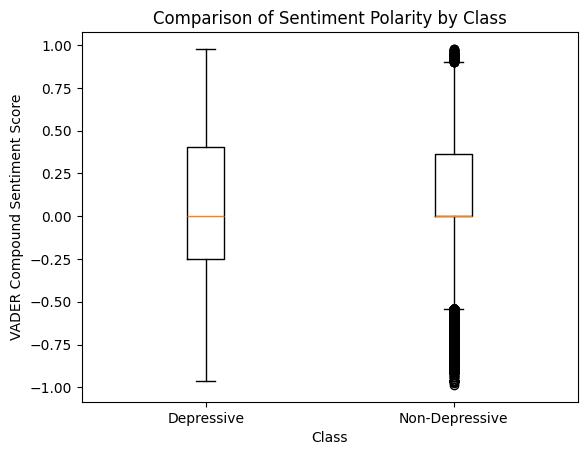

In [11]:
# Sentiment Score Distribution
plt.figure()
plt.boxplot(
    [
        df[df['label'] == 1]['sent_compound'],
        df[df['label'] == 0]['sent_compound']
    ],
    labels=['Depressive', 'Non-Depressive']
)

plt.xlabel("Class")
plt.ylabel("VADER Compound Sentiment Score")
plt.title("Comparison of Sentiment Polarity by Class")
plt.show()

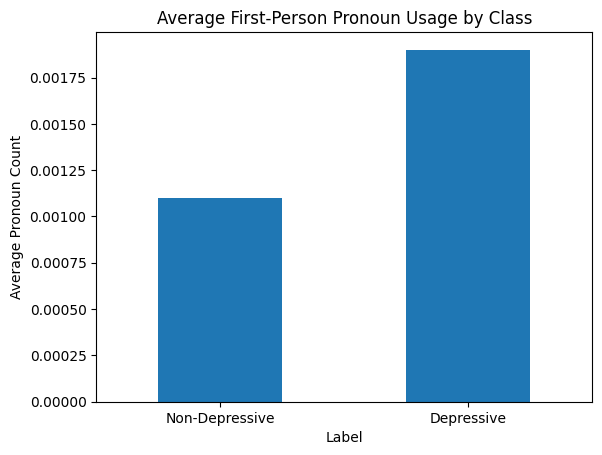

In [12]:
# Pronoun Usage Comparison
pronoun_means = df.groupby('label')['pronoun_count'].mean()

plt.figure()
pronoun_means.plot(kind='bar')
plt.xlabel("Label")
plt.ylabel("Average Pronoun Count")
plt.title("Average First-Person Pronoun Usage by Class")
plt.xticks([0, 1], ["Non-Depressive", "Depressive"], rotation=0)
plt.show()

# ML Models

In [13]:
# Combine text-based features (BoW + TF-IDF)
X_text = hstack([X_bow, X_tfidf])

# Combine sentiment + linguistic features
X_extra = df[
    ['sent_compound', 'sent_pos', 'sent_neg', 'sent_neu',
     'word_count', 'pronoun_count', 'emotion_word_count']
].values

# Final feature matrix
X_all = hstack([X_text, X_extra])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
lr_model = LogisticRegression(max_iter=2000, solver='liblinear')

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

# Grid Search with 5-Fold Cross-Validation
grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best model
best_lr_model = grid_search.best_estimator_

print("Best Hyperparameters:")
print(grid_search.best_params_)

lr_predictions = best_lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions) * 100

print("\nLogistic Regression")
print("Accuracy:", round(lr_accuracy, 2),"%")
print("\nClassification Report:\n", classification_report(y_test, lr_predictions))

Best Hyperparameters:
{'C': 1, 'penalty': 'l2'}

Logistic Regression
Accuracy: 76.08 %

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.76      2000
           1       0.76      0.75      0.76      2000

    accuracy                           0.76      4000
   macro avg       0.76      0.76      0.76      4000
weighted avg       0.76      0.76      0.76      4000



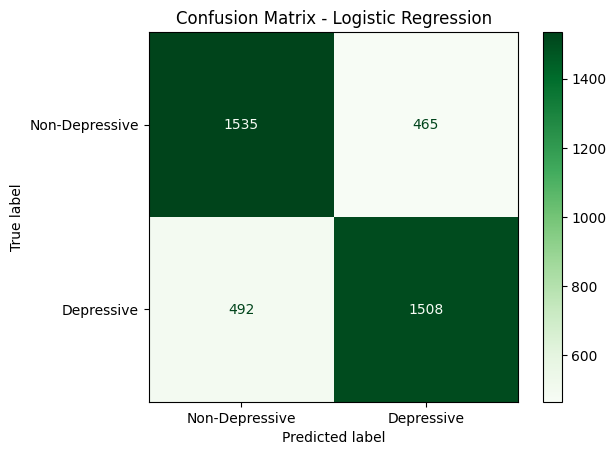

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Depressive", "Depressive"]
).plot(cmap="Greens")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [15]:
# Support Vector Machine
svm = LinearSVC(max_iter=5000)

svm_grid = {
'C':[0.01,0.1,1,10],
'class_weight':[None,'balanced']
}

grid_svm = GridSearchCV(
svm,
svm_grid,
cv=5,

scoring='recall',
n_jobs=-1
)

grid_svm.fit(X_train,y_train)
best_svm = grid_svm.best_estimator_

print("Best Hyperparameters:")
print(grid_svm.best_params_)

svm_predictions = best_svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_predictions) * 100

print("\nSupport Vector Machine")
print("Accuracy:", round(svm_accuracy, 2),"%")
print("\nClassification Report:\n")
print(classification_report(y_test, svm_predictions))

Best Hyperparameters:
{'C': 0.1, 'class_weight': None}

Support Vector Machine
Accuracy: 75.88 %

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      2000
           1       0.76      0.76      0.76      2000

    accuracy                           0.76      4000
   macro avg       0.76      0.76      0.76      4000
weighted avg       0.76      0.76      0.76      4000



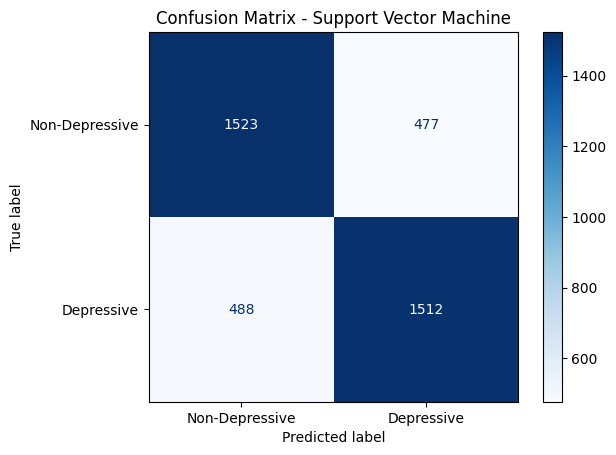

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, svm_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Depressive", "Depressive"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Support Vector Machine")
plt.show()

In [17]:
# Train-test split
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Naive Bayes
nb_grid = {
'alpha':[0.1,0.5,1,2]
}

grid_nb = GridSearchCV(
MultinomialNB(),
nb_grid,
cv=5,

scoring='recall'
)
grid_nb.fit(X_train_nb, y_train_nb)
best_nb = grid_nb.best_estimator_

print("Best Hyperparameter:")
print(grid_nb.best_params_)

nb_predictions = best_nb.predict(X_test_nb)
nb_accuracy = accuracy_score(y_test_nb, nb_predictions) * 100

print("\nNaive Bayes")
print("Accuracy:", round(nb_accuracy, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test_nb, nb_predictions))

Best Hyperparameter:
{'alpha': 2}

Naive Bayes
Accuracy: 74.78 %

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.72      0.74      2000
           1       0.74      0.77      0.75      2000

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000



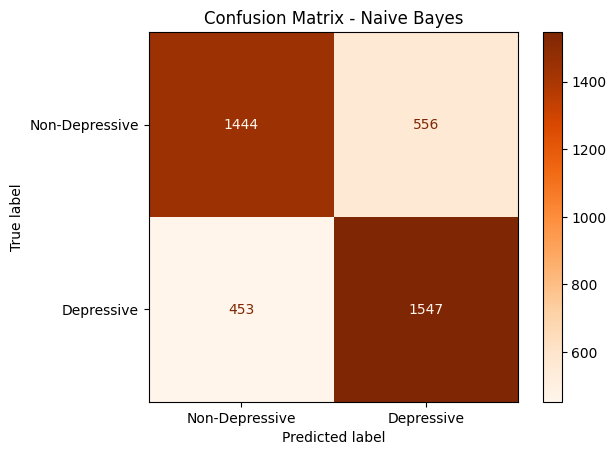

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test_nb, nb_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Depressive", "Depressive"]
).plot(cmap="Oranges")

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

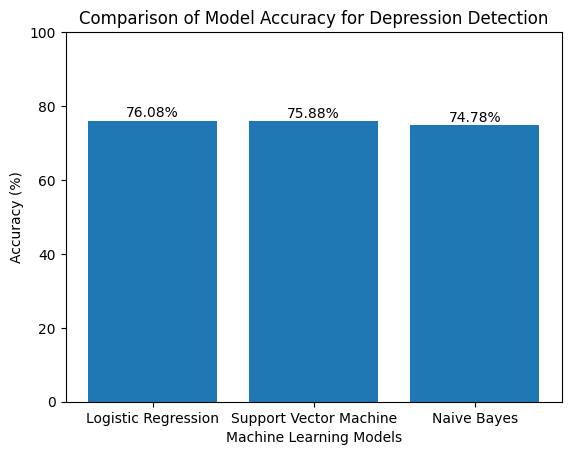

In [19]:
# Model Accuracy Comparison Plot
models = ['Logistic Regression', 'Support Vector Machine', 'Naive Bayes']
accuracies = [lr_accuracy, svm_accuracy, nb_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Model Accuracy for Depression Detection')
plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f"{round(value, 2)}%", ha='center')

plt.show()

In [20]:
# Feature Importance Analysis (Logistic Regression)
feature_names = (
    list(bow_vectorizer.get_feature_names_out()) +
    list(tfidf_vectorizer.get_feature_names_out()) +
    [
        'sent_compound',
        'sent_pos',
        'sent_neg',
        'sent_neu',
        'word_count',
        'pronoun_count',
        'emotion_word_count'
    ]
)

coefficients = best_lr_model.coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

print("\nTop 15 Features Indicating Depression")
print(importance.sort_values("Coefficient", ascending=False).head(15))

print("\nTop 15 Features Indicating Non-Depression")
print(importance.sort_values("Coefficient").head(15))


Top 15 Features Indicating Depression
         Feature  Coefficient
2873    migraine     2.471677
1188  depression     2.464955
1984    headache     2.335933
8310      people     2.173835
4181          so     2.030143
4751       vegan     1.962067
2992       nanny     1.848477
9456        talk     1.838618
4633   treatment     1.739768
992          cow     1.642688
589        calum     1.619112
1268        disc     1.580348
725        chill     1.554976
2804        meat     1.549499
467        bored     1.530101

Top 15 Features Indicating Non-Depression
         Feature  Coefficient
4967        yong    -3.101229
4656       trump    -2.875344
2347         joe    -2.373600
3617       putin    -2.209493
2572  lightsaber    -2.078435
4988        zayn    -2.046760
106        aleph    -2.006944
380      bellamy    -1.852272
103       albino    -1.818296
2842       merry    -1.817759
4518    thankyou    -1.804870
3915     russian    -1.725009
3917       saber    -1.690385
4771        vine  

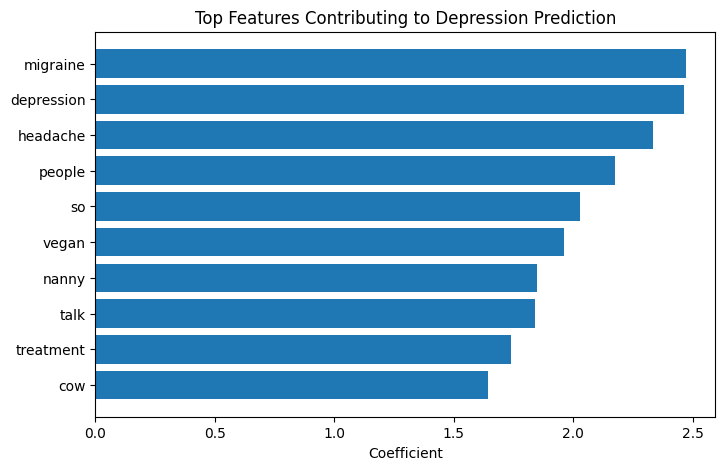

In [21]:
top_features = importance.sort_values("Coefficient", ascending=False).head(10)
plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Top Features Contributing to Depression Prediction")
plt.gca().invert_yaxis()
plt.show()